In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/project_3/uber_cleaned.xlsx')

In [ ]:
df.head()

,Row_ID,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,...,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Datetime,Hour,DayOfWeek
0,0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday
1,1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,...,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday
2,2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,...,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday
3,3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,...,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday
4,4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,...,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday


##Q7. How does customer behaviour vary by ride distance?

Why: Bins distance into segments so we can compare rating, payment mix, vehicle choice, and completion rate across short vs long trips, reveals if long trips are riskier/less reliable for the business.

In [ ]:
# Bin distance (only meaningful for completed rides, since distance is null otherwise)
bins = [0, 5, 15, 30, 100]
labels = ['Short (0-5km)', 'Medium (5-15km)', 'Long (15-30km)', 'Very Long (30km+)']
df['Distance_Segment'] = pd.cut(df['Ride Distance'], bins=bins, labels=labels)

In [ ]:
# 1. Avg customer rating by distance segment
rating_by_dist = df.groupby('Distance_Segment')['Customer Rating'].mean().round(2)
rating_by_dist

/tmp/ipykernel_4657/1225282006.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_by_dist = df.groupby('Distance_Segment')['Customer Rating'].mean().round(2)


,Customer Rating
Distance_Segment,
Short (0-5km),4.40
Medium (5-15km),4.40
Long (15-30km),4.40
Very Long (30km+),4.41


### 1. Customer Rating (4.40–4.41 across all distance groups)

**Insight:**
Customer ratings remain almost the same for all ride distances. Trip length has little to no impact on customer satisfaction.

**Recommendation:**
No need for separate service improvements based on ride distance. The current data does not support investing in special features for longer rides.

---

In [ ]:
# 2. Payment method mix by distance segment
payment_by_dist = pd.crosstab(df['Distance_Segment'], df['Payment Method'], normalize='index').round(2)
payment_by_dist

Payment Method,Cash,Credit Card,Debit Card,UPI,Uber Wallet
Distance_Segment,,,,,
Short (0-5km),0.26,0.1,0.07,0.45,0.12
Medium (5-15km),0.24,0.1,0.08,0.45,0.12
Long (15-30km),0.25,0.1,0.08,0.45,0.12
Very Long (30km+),0.25,0.1,0.08,0.45,0.12


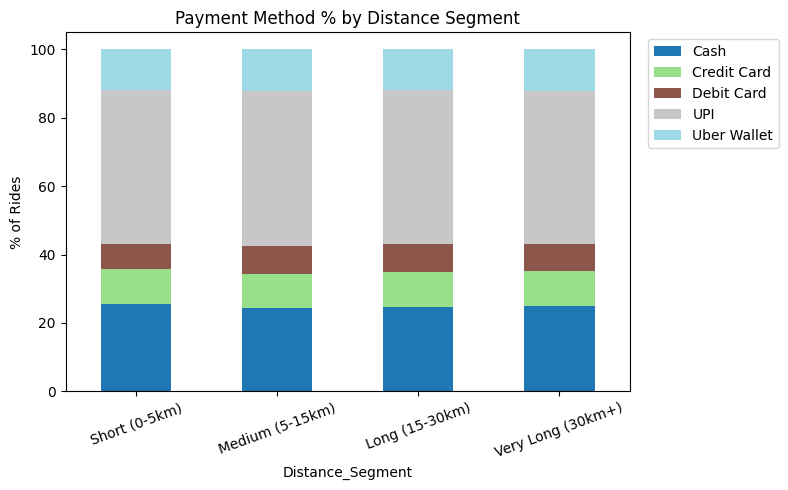

In [ ]:
import matplotlib.pyplot as plt
payment_by_dist = pd.crosstab(df['Distance_Segment'], df['Payment Method'], normalize='index') * 100

payment_by_dist.plot(kind='bar', stacked=True, figsize=(8,5), colormap='tab20')
plt.title('Payment Method % by Distance Segment')
plt.ylabel('% of Rides')
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

### 2. Payment Method (UPI ~45%, Cash ~25%)

**Insight:**
Customers use the same payment methods regardless of ride distance. UPI is the most preferred payment option across all segments.

**Recommendation:**
Promote UPI across the entire platform instead of creating distance-based payment offers.

---

In [ ]:
# 3. Vehicle preference by distance segment
vehicle_by_dist = pd.crosstab(df['Distance_Segment'], df['Vehicle Type'], normalize='index').round(2)
vehicle_by_dist

Vehicle Type,Auto,Bike,Go Mini,Go Sedan,Premier Sedan,Uber XL,eBike
Distance_Segment,,,,,,,
Short (0-5km),0.25,0.15,0.2,0.18,0.12,0.03,0.07
Medium (5-15km),0.25,0.15,0.2,0.18,0.12,0.03,0.07
Long (15-30km),0.25,0.15,0.2,0.18,0.12,0.03,0.07
Very Long (30km+),0.25,0.15,0.2,0.18,0.12,0.03,0.07


### 3. Vehicle Preference (Auto 25%, Bike 15%, Go Mini 20%)

**Insight:**
Vehicle choice remains fairly consistent across all ride distances. Customers do not significantly change their preferred vehicle type for shorter or longer trips.

**Recommendation:**
Plan vehicle supply based on overall city demand rather than creating separate fleet strategies for different ride distances.

---

In [ ]:
# 4. Completion vs Cancellation rate by distance segment
# Need full df (not just completed) — recompute segment on ALL rows using Ride Distance where available
status_by_dist = pd.crosstab(df['Distance_Segment'], df['Booking Status'], normalize='index').round(2)
status_by_dist

Booking Status,Completed,Incomplete
Distance_Segment,,
Short (0-5km),0.76,0.24
Medium (5-15km),0.80,0.20
Long (15-30km),0.93,0.07
Very Long (30km+),1.00,0.00


### 4. Ride Completion Rate (76% for Short Rides → 100% for Very Long Rides)

**Insight:**
This is the most important finding. Around 24% of short rides (0–5 km) remain incomplete, while rides over 30 km have a 100% completion rate.

**Note:** This analysis only includes rides with recorded distance. Fully cancelled or "No Driver Found" bookings are excluded because they have no distance information. Therefore, this measures **incomplete rides after the trip started**, not the overall booking failure rate.

**Recommendation:**
Identify why short trips fail after starting, such as low driver incentives for short fares or operational issues. Improving short-trip completion should be a higher priority than changing pricing or services based on ride distance.

---

##Q8. Where are the biggest revenue opportunities?
Why: Each cut isolates where money is made vs where money is lost, this is the core of the "recommendation" section recruiters look for.

In [ ]:
completed = df[df['Booking Status'] == 'Completed']

In [ ]:
# 1. High revenue locations (pickup)
revenue_by_pickup = completed.groupby('Pickup Location')['Booking Value'].sum().sort_values(ascending=False).head(10)
revenue_by_pickup

,Booking Value
Pickup Location,
Barakhamba Road,309713.0
Khandsa,309041.0
Pataudi Chowk,306774.0
Tughlakabad,299419.0
Subhash Chowk,299023.0
Badarpur,298309.0
Inderlok,296487.0
AIIMS,296028.0
ITO,292168.0


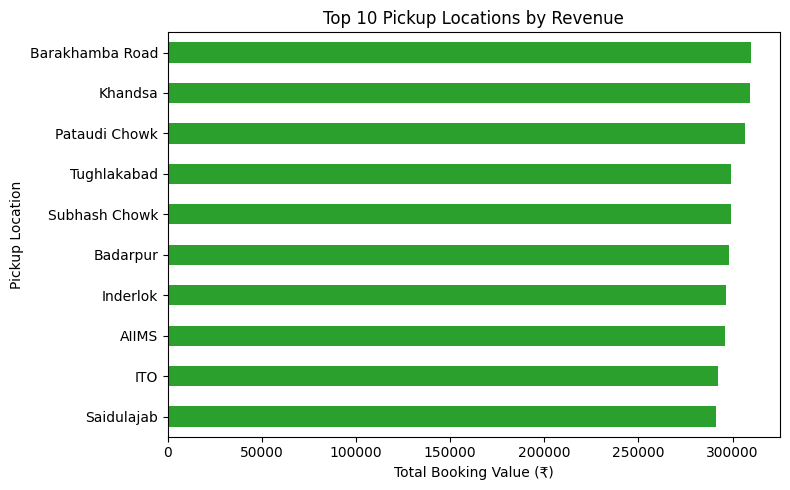

In [ ]:
completed = df[df['Booking Status'] == 'Completed']
revenue_by_pickup = completed.groupby('Pickup Location')['Booking Value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
revenue_by_pickup.sort_values().plot(kind='barh', color='#2ca02c')
plt.title('Top 10 Pickup Locations by Revenue')
plt.xlabel('Total Booking Value (₹)')
plt.tight_layout()
plt.show()

### 1. High-Revenue Locations

**Insight:**
Top pickup locations such as Barakhamba Road (₹3.10L), Khandsa (₹3.09L), and Pataudi Chowk (₹3.07L) generate similar revenue. Revenue is spread across several locations rather than being concentrated in one area.

**Recommendation:**
Maintain balanced driver availability across the top revenue-generating locations instead of focusing heavily on a single area.

---

In [ ]:
# 2. High revenue vehicle types
revenue_by_vehicle = completed.groupby('Vehicle Type')['Booking Value'].agg(['sum','mean','count']).sort_values('sum', ascending=False)
revenue_by_vehicle

,sum,mean,count
Vehicle Type,,,
Auto,11727615.0,506.483049,23155
Go Mini,9411418.0,507.381422,18549
Go Sedan,8538560.0,512.026865,16676
Bike,7144913.0,509.114508,14034
Premier Sedan,5733655.0,509.567632,11252
eBike,3298157.0,503.458556,6551
Uber XL,1406256.0,505.302192,2783


### 2. High-Revenue Vehicle Types

**Insight:**
Auto generates the highest total revenue (₹1.17Cr from 23,155 rides). However, the average fare is almost the same for all vehicle types (₹503–₹512). Higher revenue comes from more rides, not higher fares.

**Recommendation:**
Focus on increasing ride volume, especially for Auto and Go Mini, instead of promoting premium vehicle upgrades.

---

In [ ]:
# 3. High revenue time slots
revenue_by_hour = completed.groupby('Hour')['Booking Value'].sum().sort_values(ascending=False)
revenue_by_hour.head(10)

,Booking Value
Hour,
18,3908167.0
17,3522394.0
19,3395818.0
10,3057782.0
20,3035369.0
16,3012213.0
11,2637838.0
9,2631271.0
21,2625391.0


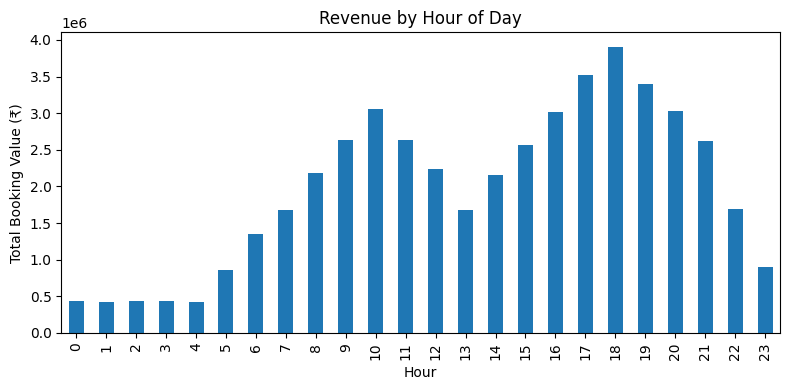

In [ ]:
revenue_by_hour = completed.groupby('Hour')['Booking Value'].sum().sort_index()

plt.figure(figsize=(8,4))
revenue_by_hour.plot(kind='bar', color='#1f77b4')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Total Booking Value (₹)')
plt.tight_layout()
plt.show()

### 3. High-Revenue Time Slots

**Insight:**
The evening peak (5 PM–9 PM) generates the highest revenue. Hour 18 (6 PM–7 PM) alone contributes ₹39.08L, nearly twice the revenue of an average off-peak hour.

**Recommendation:**
Ensure enough drivers are available during evening peak hours to reduce cancellations and maximize revenue.

---

In [ ]:
# 4. High revenue days
revenue_by_day = completed.groupby('DayOfWeek')['Booking Value'].sum().sort_values(ascending=False)
revenue_by_day

,Booking Value
DayOfWeek,
Sunday,8798697.0
Saturday,8740187.0
Friday,6090143.0
Wednesday,6011228.0
Thursday,5956180.0
Monday,5834906.0
Tuesday,5829233.0



### 4. High-Revenue Days

**Insight:**
Weekends perform much better than weekdays. Sunday (₹87.99L) and Saturday (₹87.40L) generate about 45% more revenue than a typical weekday (₹58–61L).

**Recommendation:**
Offer additional driver incentives on weekends to improve driver availability and capture higher demand.

---

In [ ]:
# 5. Booking Value distribution (check for outliers/skew)
booking_value_stats = completed['Booking Value'].describe()
booking_value_stats

,Booking Value
count,93000.000000
mean,508.178215
std,396.058769
min,50.000000
25%,234.000000
50%,414.000000
75%,689.000000
max,4277.000000


### 5. Booking Value Distribution

**Insight:**
The median fare is ₹414, while the average fare is ₹508. This shows that a small number of expensive trips increase the average fare. The highest recorded fare is ₹4,277.

**Recommendation:**
Use the median fare when evaluating a typical ride. Also, analyze high-value trips separately to identify opportunities such as airport or premium ride services.

---

In [ ]:
# 6. Revenue LOST from cancellations
# Cancelled rides have no Booking Value (ride never happened) — so we estimate lost revenue
# using avg booking value per vehicle type as proxy
avg_value_by_vehicle = completed.groupby('Vehicle Type')['Booking Value'].mean()

cancelled = df[df['Booking Status'].isin(['Cancelled by Customer','Cancelled by Driver'])]
cancelled_est_loss = cancelled.groupby('Vehicle Type').size() * avg_value_by_vehicle
cancelled_est_loss = cancelled_est_loss.dropna().sort_values(ascending=False)
total_cancellation_loss = cancelled_est_loss.sum().round(0)
total_cancellation_loss

np.float64(19057396.0)


### 6. Revenue Lost from Cancellations

**Insight:**
An estimated ₹1.90Cr in revenue was lost due to ride cancellations (calculated using the average fare by vehicle type, since cancelled rides have no actual fare).

**Recommendation:**
This loss is about **16% of the ₹11.7Cr revenue from completed rides**, making cancellation reduction a high business priority. Focus on the main cancellation reasons identified in earlier analysis.

---

In [ ]:
# 7. Revenue LOST from incomplete rides
# Incomplete rides sometimes DO have Booking Value (partial trip) — check both cases
incomplete = df[df['Incomplete Rides'] == 1]
incomplete_actual_value = incomplete['Booking Value'].sum().round(0)  # revenue partially captured
incomplete_missing_value_rows = incomplete['Booking Value'].isna().sum()  # rows with no value at all
incomplete_actual_value

np.float64(4585609.0)


### 7. Revenue from Incomplete Rides

**Insight:**
Incomplete rides still generated ₹45.86L in revenue, showing that many trips ended after the ride had already started and partial fares were collected.

**Recommendation:**
Treat incomplete rides as a service quality issue rather than only a revenue problem. Although some revenue is earned, poor customer experience can reduce customer retention and future bookings.

---

# Overall Business Insight

Revenue is strong and well distributed across locations and vehicle types. Business growth is mainly driven by **ride volume**, not higher fares. Weekends and evening hours are the most valuable periods and should receive the highest operational focus.

The two biggest business challenges are:

1. **Short-distance rides have a high incomplete rate (24%),** indicating a service reliability issue.
2. **Ride cancellations result in an estimated ₹1.90Cr revenue loss,** making cancellation reduction a key opportunity to improve both revenue and customer experience.

Improving ride reliability and reducing cancellations should be the top priorities, as these operational improvements are likely to deliver greater business impact than pricing or service changes.